In [2]:
# --- 0) Imports & paths ---
import os, numpy as np, scanpy as sc
from anndata import AnnData
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# PyTorch imports
import torch
from torch.utils.data import TensorDataset, DataLoader

# Mixed diffusion imports
from mixed_diffusion.train import train
from mixed_diffusion.models.get_model import get_model
from mixed_diffusion.main_utils import get_device
from mixed_diffusion.config_manager import load_model_config
from mixed_diffusion.model_handler import load_existing_model
from mixed_diffusion.preprocessing.data_transformer import DataTransformer
np.random.seed(42)


In [3]:
rho = "4.0"
folder = f"/Users/dm954/Documents/code/mixed_diffusion/results/synthetic_archetypes/medium/15pca_modified/gibbs200_rho{rho}-{rho}_rep1/"
saved_data = torch.load(folder + "denoising_results.pt", weights_only=False, map_location="cpu")
labels = saved_data["x_denoised_labels"]

label_mask = labels == 4

print(label_mask.shape)
print(saved_data["x_denoised"].shape)

train_and_test = np.vstack([saved_data["x_train"], saved_data["x_noised"]])

reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0)
reducer.fit(train_and_test)

torch.Size([2000])
torch.Size([2000, 15])


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP(min_dist=0.3, n_jobs=1, random_state=0, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

(419,)


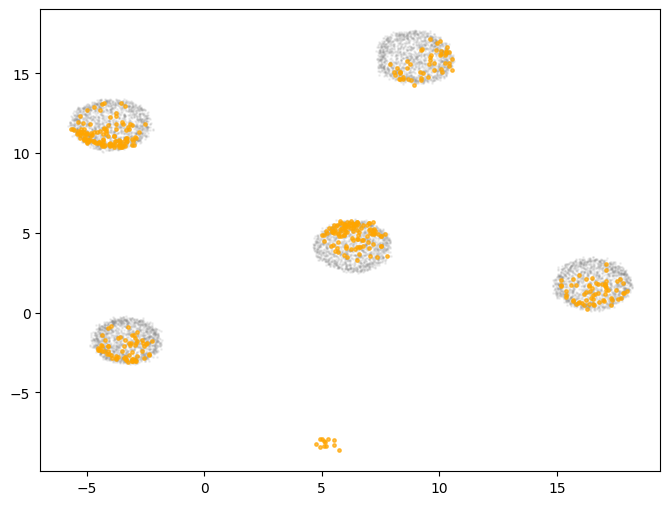

In [4]:
embedding = reducer.transform(saved_data["x_denoised"].numpy())

train_embedding = reducer.transform(saved_data["x_train"].numpy())
plt.figure(figsize=(8,6))
plt.scatter(train_embedding[:, 0], train_embedding[:, 1], s=1, alpha=0.1, c='gray')
plt.scatter(embedding[label_mask, 0], embedding[label_mask, 1], s=6, alpha=0.7, c="orange")

# plt.text(train_embedding[:, 0].mean(), train_embedding[:, 1].mean(), str(label+1), ha="center", va="center", color='red', fontsize=12,
#         bbox = dict(boxstyle=f"circle,pad={.3}", fc="lightgrey"))
#plt.annotate("Ground truth cluster", xy=(train_embedding[:, 0].mean(), train_embedding[:, 1].mean()), xytext=(5, 18), color='black', fontsize=15, arrowprops=dict(facecolor='black',shrink=0.05))
print(embedding[label_mask, 0].shape)

plt.savefig(f"../../figures/new_cluster_rho{rho}.pdf")
plt.show()


In [5]:
saved_data.keys()

dict_keys(['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config'])

In [6]:
np.load("C_test_modified.npy").shape

(2000, 200)

(419,)


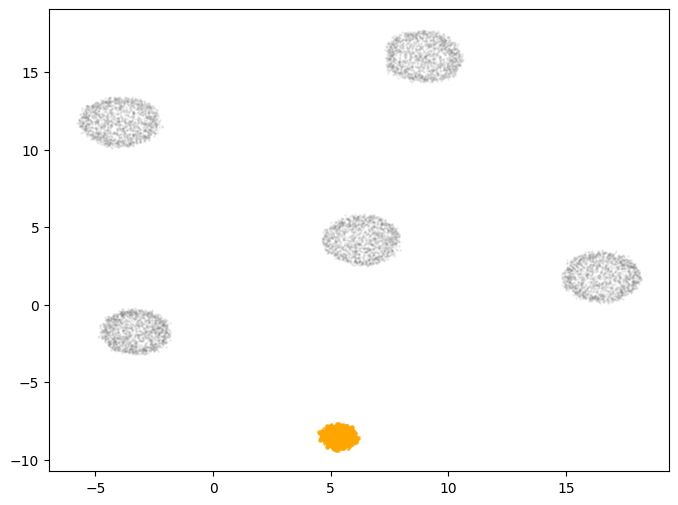

In [8]:
embedding = reducer.transform(saved_data["x_noised"].numpy())

train_embedding = reducer.transform(saved_data["x_train"].numpy())
plt.figure(figsize=(8,6))
plt.scatter(train_embedding[:, 0], train_embedding[:, 1], s=1, alpha=0.1, c='gray')
plt.scatter(embedding[label_mask, 0], embedding[label_mask, 1], s=6, alpha=0.7, c="orange")

# plt.text(train_embedding[:, 0].mean(), train_embedding[:, 1].mean(), str(label+1), ha="center", va="center", color='red', fontsize=12,
#         bbox = dict(boxstyle=f"circle,pad={.3}", fc="lightgrey"))
#plt.annotate("Ground truth cluster", xy=(train_embedding[:, 0].mean(), train_embedding[:, 1].mean()), xytext=(5, 18), color='black', fontsize=15, arrowprops=dict(facecolor='black',shrink=0.05))
print(embedding[label_mask, 0].shape)

plt.savefig(f"../../figures/new_cluster_pca.pdf")
plt.show()
